# Mining Process – % Silica Concentrate Prediction

This project aims to develop a **machine learning regression model** to predict the **% Silica Concentrate** in a mining flotation process using operational plant data.  
Accurate prediction of silica concentration is essential to improve process efficiency, reduce laboratory dependency, and support real-time decision-making in the field. The code is divided into five main parts, which are:
1. Imports & Configurations;
2. Dataset Treatment;  
3. Applying Ensemble Model; 
4. Result Analysis;
5. Predicting the Future.


**Responsible:** Paulo Casmal

**Email:** <paulo.casmal@gmail.com>

**Start Date:** 01-31-2026 | **Submission Date:** 


---


## 01 - Imports & Configurations

In [1]:
# import necessary libraries
import locale
import warnings

import pandas as pd
import numpy as np  
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit #, GridSearchCV
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA

from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [2]:
# Configuration of matplotlib parameters for consistent styling
mpl.rcParams['figure.figsize'] = (7, 5)  # Default figure size
mpl.rc('lines', lw=1.5)  # Sets the line width
mpl.rcParams['grid.linewidth'] = 0.5  # Grid line width
mpl.rcParams['grid.linestyle'] = 'dashed'  # Grid line style
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size
mpl.rcParams['axes.linewidth'] = 0.5 # - Largura das bordas dos gráficos

In [3]:
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'portuguese_brazil')

# 2. Informa ao Matplotlib para usar o separador do locale
mpl.rcParams['axes.formatter.use_locale'] = True

In [4]:
# Load the dataset
path = r'C:\Users\paulo\Downloads\archive (2)\MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(path, decimal=',')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 02 - Dataset treatment

In [5]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [6]:
df.columns

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Drop the '% Iron Concentrate' column due to high correlation with target variable. Additionaly, this variable can be measured only at laboratory, which not helps to predict the '% Silica Concentrate' in field.

In [7]:
df = df[['% Iron Concentrate', '% Silica Concentrate']]

In [8]:
df = df.resample("1H").mean()

In [9]:
df = df.drop_duplicates(keep='first')

EDA was performed in a separate script. It does not indicate any major problem with data.

In [10]:
df = df.rename(columns={'% Iron Concentrate': 'Iron_Concentrate', '% Silica Concentrate': 'Silica_Concentrate'})
df = df.drop(columns=['Iron_Concentrate'])

### 2.3 - Lag Features

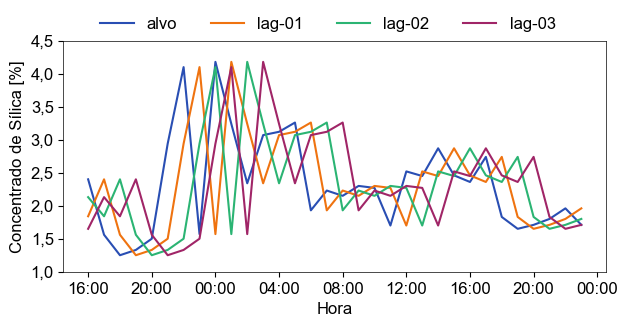

In [11]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

# Just for visualization purposes
view = df.sort_index().copy()

view = view[view.index > '2017-09-08 00:00:00']

target_col = "Silica_Concentrate"

for lag in range(1, 15):
    view[f"lag-{lag}"] = view[target_col].shift(lag)

view = view.dropna()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(view.index, view['Silica_Concentrate'], label='alvo', c='#294EB3')
ax.plot(view.index, view['lag-1'], c='#EF7310', label='lag-01')
ax.plot(view.index, view['lag-2'], c='#2BB473', label='lag-02')
ax.plot(view.index, view['lag-3'], c="#A02567", label='lag-03')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.legend(ncol=4, loc='upper left', bbox_to_anchor=(0.04, 1.17), frameon=False)
ax.set_ylabel('Concentrado de Sílica [%]')
ax.set_xlabel('Hora')

ax.set_yticks(np.arange(1, 5, 0.5))
# fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\lag-features.svg', dpi=140, format='svg', transparent=True)

plt.show()


In [12]:
df = df.sort_index()

target_col = "Silica_Concentrate"

for col in df.columns:
    for lag in range(1, 3):
        df[f"lag-{lag}"] = df[col].shift(lag)

# df = df.dropna()

In [13]:
# df = df.drop(columns=['Iron_Concentrate'])

### 2.4 - Cross-Validation

In [14]:
# Using specific time series train test split method
tss = TimeSeriesSplit(n_splits=5, test_size=24*14, gap=24) # 14 days data for testing

df = df.sort_index()

df = df.dropna()

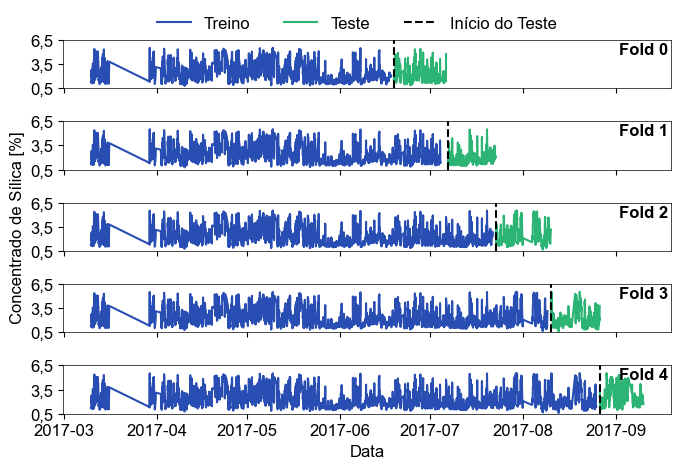

In [15]:
# Just for visualization purposes
fig, axs = plt.subplots(5, 1, figsize=(7, 5), sharex=True)

# Plot each fold
for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    axs[fold].plot(train.index, train['Silica_Concentrate'], label='Treino', c='#294EB3')
    axs[fold].plot(test.index, test['Silica_Concentrate'], label='Teste', c="#2BB473")
    axs[fold].axvline(x=test.index[0], color='k', linestyle='--', label='Início do Teste')

    axs[fold].text(0.915, 0.7, f'Fold {fold}', fontsize=12, transform=axs[fold].transAxes, fontweight='bold')

    axs[fold].set_yticks(np.arange(0.5, 7, 3))
    axs[fold].set_ylim(0.5, 6.5)


axs[2].set_ylabel('Concentrado de Sílica [%]')

axs[0].legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.8), frameon=False)

plt.xlabel('Data')
plt.tight_layout()

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\time-series-split.svg', dpi=140, format='svg', transparent=True)

plt.show()

## 03 - Comparing Models

In [16]:
df.columns

Index(['Silica_Concentrate', 'lag-1', 'lag-2'], dtype='object')

In [17]:
target = 'Silica_Concentrate'
lags_to_test = range(1, 10)

In [18]:
fig_res, ax_res = plt.subplots(figsize=(7, 3))
fig_res_2, ax_res_2 = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={'hspace':0.4})

# fig_res_2.subplots_adjust(hspace=0.45) #, wspace=0.25)

plt.close(fig_res)
plt.close(fig_res_2)

### 3.1 - XGBoost

In [19]:
# --- Configurações Iniciais ---
all_results_xgb = [] 
fold_metrics = []

# Variáveis para achar o melhor modelo (Grande Campeão baseado em R2)
best_model_xgb = None 
best_r2_xgb = -np.inf  # Iniciamos com o menor valor possível

# 2. Cross-Validation
tss = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    X_train_full = train.drop(columns=[target])
    y_train_full = train[target]
    X_test = test.drop(columns=[target])
    y_test = test[target]

    # Split validação para Early Stopping (90/10)
    split_idx = int(len(X_train_full) * 0.9)
    X_train, X_val = X_train_full.iloc[:split_idx], X_train_full.iloc[split_idx:]
    y_train, y_val = y_train_full.iloc[:split_idx], y_train_full.iloc[split_idx:]

    # Instanciando XGBoost
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=3,
        objective='reg:squarederror',
        early_stopping_rounds=50, 
        random_state=42,
        n_jobs=-1
    )

    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False 
    )

    y_pred_xgb = model_xgb.predict(X_test)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2 = r2_score(y_test, y_pred_xgb)
    mae = mean_absolute_error(y_test, y_pred_xgb)
    
    fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

    # --- LÓGICA DO CAMPEÃO BASEADA EM R2 ---
    if r2 > best_r2_xgb:
        best_r2_xgb = r2
        best_model_xgb = model_xgb

        # Salvando o contexto correto para o teste posterior bater com o resultado
        X_test_xgb = X_test.copy()
        y_test_xgb = y_test.copy()

    if fold == 4:
        ax_res.plot(y_test.index, y_test, label='Real', c='k')
        ax_res.plot(y_test.index, y_pred_xgb, label='XGB', c='#294EB3', alpha=0.75)
        ax_res_2[0].scatter(y_test, y_pred_xgb, c='#294EB3', alpha=0.75)
        ax_res_2[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.5)
        ax_res_2[1].hist(y_test - y_pred_xgb, bins=30, color='#294EB3', alpha=0.75)
    
    print(f'Fold: {fold} -- R2: {r2:.2f} -- RMSE: {rmse:.2f}')

# 3. Resumo Final
avg_r2 = np.mean([m['r2'] for m in fold_metrics])

print("-" * 30)
print(f'R2 Médio (CV): {avg_r2:.2f}')
print(f'Melhor R2 Único: {best_r2_xgb:.2f}')

Fold: 0 -- R2: 0.48 -- RMSE: 0.84
Fold: 1 -- R2: 0.52 -- RMSE: 0.68
Fold: 2 -- R2: 0.40 -- RMSE: 0.72
Fold: 3 -- R2: 0.55 -- RMSE: 0.75
Fold: 4 -- R2: 0.62 -- RMSE: 0.73
------------------------------
R2 Médio (CV): 0.51
Melhor R2 Único: 0.62


### 3.2 - Random Forest

In [20]:
# --- Configurações Iniciais ---
all_results_rf = [] 
best_model_rf = None 
best_r2_rf = -np.inf # Iniciamos com infinito negativo para encontrar o MAIOR

fold_metrics_rf = []

# Variáveis para o melhor modelo desta configuração (baseado em R²)
temp_best_model_rf = None
temp_best_r2_rf = -np.inf 

# 1. Cross-Validation
tss = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tss.split(df)):
    # Seleção dos dados do fold
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    X_train = train.drop(columns=[target])
    y_train = train[target]
    X_test = test.drop(columns=[target])
    y_test = test[target]

    # 2. Instanciando Random Forest
    # Dica: max_features='sqrt' ou 'log2' costuma ajudar no R2 em dados tabulares
    model_rf = RandomForestRegressor(
        n_estimators=200, 
        max_depth=12,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )

    # 3. Treino
    model_rf.fit(X_train, y_train)

    # 4. Predição e Métricas
    y_pred_rf = model_rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)
    
    fold_metrics_rf.append({'rmse': rmse, 'r2': r2, 'mae': mae})

    # --- LÓGICA DE PRIORIZAÇÃO DO R² ---
    # Agora buscamos o MAIOR R2 (proximidade de 1.0)
    if r2 > best_r2_rf:
        best_r2_rf = r2
        best_model_rf = model_rf

        # Guardando o contexto do melhor R2 para validação futura
        X_test_rf = X_test.copy()
        y_test_rf = y_test.copy()

    print(f'Fold: {fold} -- R2: {np.round(r2, 2)} -- RMSE: {np.round(rmse, 2)}')

    if fold == 4:
        ax_res.plot(y_test_rf.index, y_pred_rf, label='RF', c='#DA1C1C', alpha=0.75)
        ax_res_2[0].scatter(y_test_rf, y_pred_rf, c='#DA1C1C', alpha=0.75)
        ax_res_2[1].hist(y_test_rf - y_pred_rf, bins=30, color='#DA1C1C', alpha=0.75)

# 5. Média das métricas
avg_r2_rf = np.mean([m['r2'] for m in fold_metrics_rf])
print("-" * 30)
print(f'R² Médio do Experimento: {avg_r2_rf:.2f}')
print(f'Melhor R² de um único Fold: {temp_best_r2_rf:.2f}')

Fold: 0 -- R2: 0.51 -- RMSE: 0.82
Fold: 1 -- R2: 0.47 -- RMSE: 0.71
Fold: 2 -- R2: 0.3 -- RMSE: 0.78
Fold: 3 -- R2: 0.52 -- RMSE: 0.78
Fold: 4 -- R2: 0.6 -- RMSE: 0.75
------------------------------
R² Médio do Experimento: 0.48
Melhor R² de um único Fold: -inf


### 3.3 - Multi Layer Perceptron

In [21]:
# --- Configurações Iniciais ---
fold_metrics_mlp = []
best_model_mlp = None 
best_r2_mlp = -np.inf 

# 2. Cross-Validation
tss = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    X_train = train.drop(columns=[target])
    y_train = train[target]
    X_test = test.drop(columns=[target])
    y_test = test[target]

    # --- IMPORTANTE: Scaling para Redes Neurais ---
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    # Ajustamos o scaler apenas nos dados de treino para evitar data leakage
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)
    
    # Opcional: Scaler no target ajuda na convergência
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    # 3. Instanciando MLP
    # hidden_layer_sizes: (100, 50) cria duas camadas ocultas
    model_mlp = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True, # MLP do sklearn tem early stopping nativo
        validation_fraction=0.1,
        random_state=42,
        learning_rate_init=0.001
    )

    # 4. Treino
    model_mlp.fit(X_train_scaled, y_train_scaled)

    # 5. Predição (Voltando para a escala original se usou scaler no Y)
    y_pred_scaled = model_mlp.predict(X_test_scaled)
    y_pred_mlp = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    r2 = r2_score(y_test, y_pred_mlp)
    mae = mean_absolute_error(y_test, y_pred_mlp)
    
    fold_metrics_mlp.append({'rmse': rmse, 'r2': r2, 'mae': mae})

    # --- LÓGICA DO CAMPEÃO BASEADA EM R2 ---
    if r2 > best_r2_mlp:
        best_r2_mlp = r2
        best_model_mlp = model_mlp

        scaler_x_mlp = scaler_x
        scaler_y_mlp = scaler_y
        X_test_mlp = X_test.copy()
        y_test_mlp = y_test.copy()

    print(f'Fold: {fold} -- R2: {r2:.2f} -- RMSE: {rmse:.2f}')

    if fold == 4:
        ax_res.plot(y_test_mlp.index, y_pred_mlp, label='MLP', c='#EF7310', alpha=0.75)
        ax_res_2[0].scatter(y_test_mlp, y_pred_mlp, c='#EF7310', alpha=0.75)
        ax_res_2[1].hist(y_test_mlp - y_pred_mlp, bins=30, color='#EF7310', alpha=0.75)

# Resumo
avg_r2_mlp = np.mean([m['r2'] for m in fold_metrics_mlp])
print("-" * 30)
print(f'R2 Médio: {avg_r2_mlp:.2f}')
print(f'Melhor R2: {best_r2_mlp:.2f}')

Fold: 0 -- R2: 0.56 -- RMSE: 0.78
Fold: 1 -- R2: 0.56 -- RMSE: 0.66
Fold: 2 -- R2: 0.43 -- RMSE: 0.70
Fold: 3 -- R2: 0.57 -- RMSE: 0.73
Fold: 4 -- R2: 0.63 -- RMSE: 0.72
------------------------------
R2 Médio: 0.55
Melhor R2: 0.63


### 3.4 - ARIMAX

In [22]:
# 1. Silenciar avisos e inicializar variáveis
warnings.filterwarnings("ignore")

# ESSA LINHA RESOLVE O ERRO DO PRINT:
fold_metrics_arma = [] 
best_r2_arma = -np.inf
best_model_arma = None

# 2. Configurar Cross-Validation
tss = TimeSeriesSplit(n_splits=5)

print("Iniciando ARIMA(2,1,0) com Walk-Forward...")

for fold, (train_index, test_index) in enumerate(tss.split(df)):
    y_train = df[target].iloc[train_index]
    y_test = df[target].iloc[test_index]

    
    history = list(y_train)
    predictions = []

    # Walk-forward (prever 1 passo e atualizar)
    for t in range(len(y_test)):
        # Mudamos para (2, 1, 0) porque seu ACF decai lentamente
        model = ARIMA(history, order=(2, 1, 0)) 
        model_fit = model.fit()
        
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(y_test[t])

    # Métricas
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    # Agora a lista já existe e o .append() funciona:
    fold_metrics_arma.append({'rmse': rmse, 'r2': r2})

    if r2 > best_r2_arma:
        best_r2_arma = r2
        best_model_arma = model_fit
        
        X_test_arma = X_test.copy()
        y_test_arma = y_test.copy()

    print(f'Fold: {fold} | R2: {r2:.4f} | RMSE: {rmse:.4f}')

    if fold == 4:
        ax_res.plot(y_test_arma.index, predictions, label='ARIMA', c='#2BB449', alpha=0.75)
        ax_res_2[0].scatter(y_test_arma, predictions, c='#2BB449', alpha=0.75)
        ax_res_2[1].hist(y_test_arma - predictions, bins=30, color='#2BB449', alpha=0.75)

# 3. Resumo Final
if fold_metrics_arma:
    avg_r2 = np.mean([m['r2'] for m in fold_metrics_arma])
    print(f"\n--- Resultado Final ---")
    print(f"R2 Médio: {avg_r2:.4f}")
    print(f"Melhor R2: {best_r2_arma:.4f}")

Iniciando ARIMA(2,1,0) com Walk-Forward...
Fold: 0 | R2: 0.5357 | RMSE: 0.8002
Fold: 1 | R2: 0.5523 | RMSE: 0.6600
Fold: 2 | R2: 0.3682 | RMSE: 0.7384
Fold: 3 | R2: 0.5352 | RMSE: 0.7657
Fold: 4 | R2: 0.6106 | RMSE: 0.7399

--- Resultado Final ---
R2 Médio: 0.5204
Melhor R2: 0.6106


### 3.5 - Long-Short Term Memory (LSTM)

In [23]:
# --- Função para criar janelas ---
def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

fold_metrics_lstm = []
best_model_lstm = None 
best_r2_lstm = -np.inf 
n_steps = 2

tss = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    X_train_raw = train.drop(columns=[target]).values
    y_train_raw = train[target].values
    X_test_raw = test.drop(columns=[target]).values
    y_test_raw = test[target].values

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_train_s = scaler_x.fit_transform(X_train_raw)
    X_test_s = scaler_x.transform(X_test_raw)
    y_train_s = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
    y_test_s = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

    X_train_3d, y_train_3d = create_sequences(X_train_s, y_train_s, n_steps)
    X_test_3d, y_test_3d = create_sequences(X_test_s, y_test_s, n_steps)

    model_lstm = Sequential([
        LSTM(1000, activation='relu', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model_lstm.fit(
        X_train_3d, y_train_3d,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # Predição
    y_pred_s = model_lstm.predict(X_test_3d)
    y_pred = scaler_y.inverse_transform(y_pred_s).flatten()

    # Ajuste do target real
    y_test_real = y_test_raw[n_steps:]
    y_test_index = test.index[n_steps:]

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    r2 = r2_score(y_test_real, y_pred)
    mae = mean_absolute_error(y_test_real, y_pred)

    fold_metrics_lstm.append({'rmse': rmse, 'r2': r2, 'mae': mae})

    if r2 > best_r2_lstm:
        best_r2_lstm = r2
        best_model_lstm = model_lstm
        scaler_x_lstm = scaler_x
        scaler_y_lstm = scaler_y

    print(f'Fold: {fold} -- R2 LSTM: {r2:.4f} -- RMSE: {rmse:.4f}')

    if fold == 4:
        ax_res.plot(y_test_index, y_pred, label='LSTM', c='#4623DF', alpha=0.75)
        ax_res_2[0].scatter(y_test_real, y_pred, c='#4623DF', alpha=0.75)
        ax_res_2[1].hist(y_test_real - y_pred, bins=30, color='#4623DF', alpha=0.75)

print("-" * 30)
avg_r2 = np.mean([m['r2'] for m in fold_metrics_lstm])
print(f'R2 Médio LSTM: {avg_r2:.4f}')





19/19 [==============================] - 0s 6ms/step
Fold: 0 -- R2 LSTM: 0.3735 -- RMSE: 0.9295
19/19 [==============================] - 0s 6ms/step
Fold: 1 -- R2 LSTM: 0.4247 -- RMSE: 0.7472
19/19 [==============================] - 0s 6ms/step
Fold: 2 -- R2 LSTM: 0.2374 -- RMSE: 0.8053
19/19 [==============================] - 0s 6ms/step
Fold: 3 -- R2 LSTM: 0.3962 -- RMSE: 0.8731
19/19 [==============================] - 0s 6ms/step
Fold: 4 -- R2 LSTM: 0.4764 -- RMSE: 0.8594
------------------------------
R2 Médio LSTM: 0.3817


## 04 - Result Analysis

### 4.1 - Ploting Model Results

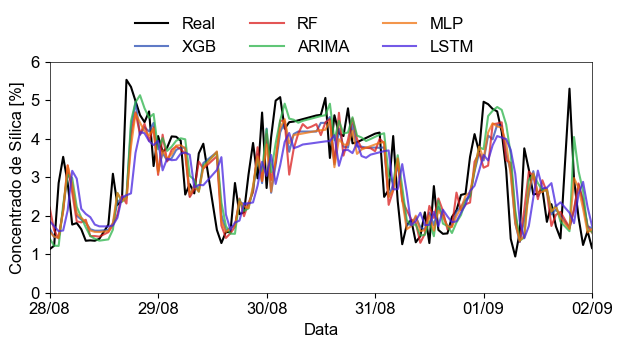

In [34]:
fig_compare, ax_compare = plt.subplots(figsize=(7, 3))

ax_compare.plot(y_test.index, y_test, label='Real', c='k')
ax_compare.plot(y_test.index, y_pred_xgb, label='XGB', c='#294EB3', alpha=0.75)
ax_compare.plot(y_test_rf.index, y_pred_rf, label='RF', c='#DA1C1C', alpha=0.75)
ax_compare.plot(y_test_arma.index, predictions, label='ARIMA', c='#2BB449', alpha=0.75)
ax_compare.plot(y_test_mlp.index, y_pred_mlp, label='MLP', c='#EF7310', alpha=0.75)
ax_compare.plot(y_test_index, y_pred, label='LSTM', c='#4623DF', alpha=0.75)

ax_compare.set_yticks(range(0, 7, 1))
ax_compare.legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.26), frameon=False)

ax_compare.set_ylabel('Concentrado de Sílica [%]')
ax_compare.set_xlabel('Data')

ax_compare.set_xlim(pd.to_datetime('2017-08-28 00:00:00'), pd.to_datetime('2017-09-02 00:00:00'))
ax_compare.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax_compare.set_xticks(pd.to_datetime(['2017-08-28 00:00:00', '2017-08-29 00:00:00', '2017-08-30 00:00:00', '2017-08-31 00:00:00', '2017-09-01 00:00:00', '2017-09-02 00:00:00']))

fig_compare.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-prediction.svg', dpi=140, format='svg', transparent=True)

plt.show()

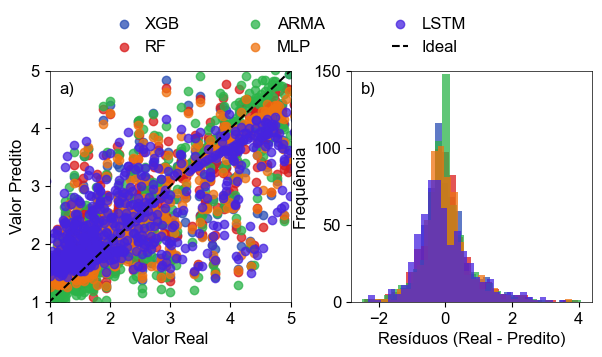

In [39]:
fig_errors, ax_errors = plt.subplots(1, 2, figsize=(7, 3))

plt.subplots_adjust(wspace=0.25)

ax_errors[0].scatter(y_test, y_pred_xgb, c='#294EB3', alpha=0.75, label='XGB')
ax_errors[1].hist(y_test - y_pred_xgb, bins=30, color='#294EB3', alpha=0.75)

ax_errors[0].scatter(y_test_rf, y_pred_rf, c='#DA1C1C', alpha=0.75, label='RF')
ax_errors[1].hist(y_test_rf - y_pred_rf, bins=30, color='#DA1C1C', alpha=0.75)

ax_errors[0].scatter(y_test_arma, predictions, c='#2BB449', alpha=0.75, label='ARMA')
ax_errors[1].hist(y_test_arma - predictions, bins=30, color='#2BB449', alpha=0.75)

ax_errors[0].scatter(y_test_mlp, y_pred_mlp, c='#EF7310', alpha=0.75, label='MLP')
ax_errors[1].hist(y_test_mlp - y_pred_mlp, bins=30, color='#EF7310', alpha=0.75)
        
ax_errors[0].scatter(y_test_real, y_pred, c='#4623DF', alpha=0.75, label='LSTM')
ax_errors[1].hist(y_test_real - y_pred, bins=30, color='#4623DF', alpha=0.75)

ax_errors[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Ideal')

ax_errors[0].set_xlabel('Valor Real')
ax_errors[0].set_ylabel('Valor Predito')

ax_errors[1].set_xlabel('Resíduos (Real - Predito)')
ax_errors[1].set_ylabel('Frequência')

ax_errors[0].legend(
    ncol=3,
    loc='upper center',
    bbox_to_anchor=(1, 1.3),
    handlelength=1,
    columnspacing=4,
    frameon=False
)

ax_errors[0].set_yticks(np.arange(1, 6, 1))
ax_errors[0].set_xticks(np.arange(1, 6, 1))

ax_errors[0].set_ylim(1, 5)
ax_errors[0].set_xlim(1, 5)

ax_errors[1].set_yticks(np.arange(0, 200, 50))

ax_errors[1].set_ylim(0, 150)

ax_errors[0].text(0.04, 0.90, 'a)', fontsize=12, transform=ax_errors[0].transAxes)
ax_errors[1].text(0.04, 0.90, 'b)', fontsize=12, transform=ax_errors[1].transAxes)

fig_errors.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-errors.svg', dpi=140, format='svg', transparent=True)

plt.show()

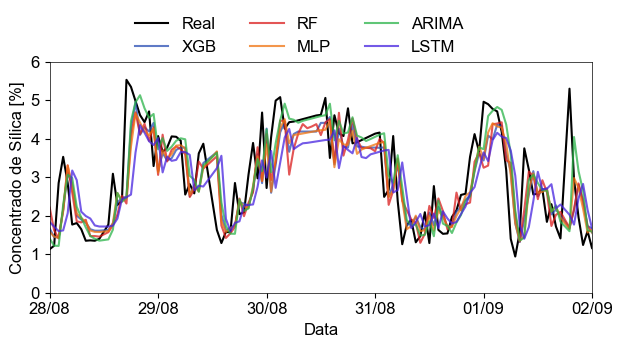

In [ ]:
# ax_res.set_yticks(range(0, 7, 1))
# ax_res.legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.26), frameon=False)

# ax_res.set_ylabel('Concentrado de Sílica [%]')
# ax_res.set_xlabel('Data')

# ax_res.set_xlim(pd.to_datetime('2017-08-28 00:00:00'), pd.to_datetime('2017-09-02 00:00:00'))
# ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

# ax_res.set_xticks(pd.to_datetime(['2017-08-28 00:00:00', '2017-08-29 00:00:00', '2017-08-30 00:00:00', '2017-08-31 00:00:00', '2017-09-01 00:00:00', '2017-09-02 00:00:00']))

# fig_res.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-prediction.svg', dpi=140, format='svg', transparent=True)
# display(fig_res)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


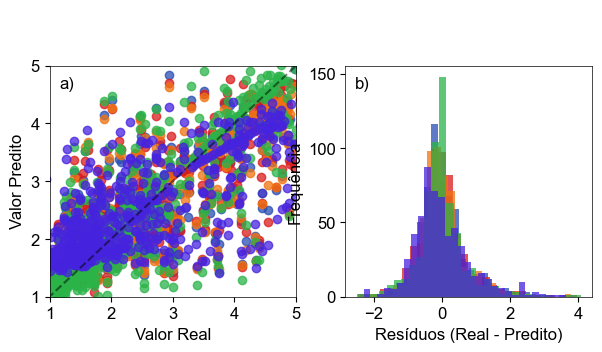

In [ ]:
# ax_res_2[0].set_xlabel('Valor Real')
# ax_res_2[0].set_ylabel('Valor Predito')

# ax_res_2[1].set_xlabel('Resíduos (Real - Predito)')
# ax_res_2[1].set_ylabel('Frequência')

# ax_res_2[0].legend(
#     ncol=3,
#     loc='upper center',
#     bbox_to_anchor=(1, 1.28),
#     handlelength=1,
#     columnspacing=4,
#     frameon=False
# )

# ax_res_2[0].set_yticks(np.arange(1, 6, 1))
# ax_res_2[0].set_xticks(np.arange(1, 6, 1))

# ax_res_2[0].set_ylim(1, 5)
# ax_res_2[0].set_xlim(1, 5)

# ax_res_2[1].set_yticks(np.arange(0, 200, 50))

# ax_res_2[0].text(0.04, 0.90, 'a)', fontsize=12, transform=ax_res_2[0].transAxes)
# ax_res_2[1].text(0.04, 0.90, 'b)', fontsize=12, transform=ax_res_2[1].transAxes)


# display(fig_res_2)

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib as mpl
# import numpy as np

# y_pred_xgb = best_model_xgb.predict(X_test)
# y_pred_rf = best_model_rf.predict(X_test)
# # y_pred_arma = best_model_arma.predict(X_test)
# y_pred_mlp = best_model_mlp.predict(X_test)

# # Dict para facilitar a plotagem (certifique-se de que as variáveis existam)
# models_data = {
#     'XGBoost': {'pred': y_pred_xgb, 'color': '#0B1741'},
#     'RF':      {'pred': y_pred_rf,  'color': '#EF7310'},
#     # 'ARIMA':   {'pred': y_pred_arma,'color': '#2BB449'},
#     'MLP':     {'pred': y_pred_mlp, 'color': '#DA1C1C'},
#     # 'LSTM':    {'pred': y_pred_lstm,'color': '#4623DF'}
# }

# # --- 2. Configurações de Estilo ---
# mpl.rc(('xtick', 'ytick'), labelsize=12)
# mpl.rc('font', family='Arial', size=12)

# fig, ax = plt.subplots(1, 2, figsize=(7, 3))
# fig.subplots_adjust(wspace=0.22)
# alp = 0.4

# # --- 3. Gráfico (a): Scatter Plot (Real vs Predição) ---
# for name, data in models_data.items():
#     # Nota: y_test deve ser o correspondente ao modelo específico 
#     # ou o y_test_real alinhado para todos
#     ax[0].scatter(data['pred'], y_test_real, c=data['color'], alpha=alp, label=name)

# # Linha Ideal
# ax[0].plot([0, 5], [0, 5], color='#000000', ls='--', label='Ideal')

# ax[0].set_xlabel('Predição')
# ax[0].set_ylabel('Valor real')
# ax[0].set_ylim(1, 5)
# ax[0].set_xlim(1, 5)

# # --- 4. Gráfico (b): Histograma de Erros ---
# for name, data in models_data.items():
#     error = np.asarray(data['pred']) - np.asarray(y_test_real)
#     ax[1].hist(error, bins=50, color=data['color'], alpha=alp, label=name)

# ax[1].set_xlabel('Erro absoluto')
# ax[1].set_ylabel('Amostras')

# # --- 5. Anotações e Legenda ---
# ax[0].text(0.03, 0.95, 'a)', transform=ax[0].transAxes, fontsize=12, va='top')
# ax[1].text(0.03, 0.95, 'b)', transform=ax[1].transAxes, fontsize=12, va='top')

# ax[0].legend(
#     ncol=3,
#     loc='upper center',
#     bbox_to_anchor=(1, 1.28),
#     handlelength=1,
#     columnspacing=4,
#     frameon=False
# )

# # --- 6. Salvamento ---
# # Certifique-se de que o caminho existe ou use um caminho relativo
# try:
#     save_path = r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-models-comparinson-errors.svg'
#     fig.savefig(save_path, dpi=140, format='svg', transparent=True, bbox_inches='tight')
#     print(f"Gráfico salvo com sucesso em: {save_path}")
# except:
#     fig.savefig('res-models-comparison.svg', dpi=140, format='svg')
#     print("Salvo no diretório local (caminho do Drive não encontrado).")

# plt.show()

# 05 - Predicting the Future

In [ ]:
# future = 24 * 2

# # índice temporal (use o do y_test correspondente)
# idx_future = y_test_xgb.iloc[-future:].index

# # colunas (use as do seu DataFrame tabular)
# cols_tabular = X_test_xgb.columns

# # garante que MLP está em DataFrame
# if not hasattr(X_test_mlps, "iloc"):
#     X_test_mlps = pd.DataFrame(X_test_mlps, columns=cols_tabular, index=y_test_mlps.index)

# X_test_future_xgb = X_test_xgb.iloc[-future:].copy()
# X_test_future_rf  = X_test_rf.iloc[-future:].copy()
# X_test_future_mlp = X_test_mlps.iloc[-future:].copy()


In [ ]:
# import numpy as np

# def recursive_forecast_tabular(model, X_seed: pd.DataFrame, horizon: int, lag_cols=None):
#     Xf = X_seed.copy(deep=True)

#     if lag_cols is None:
#         lag_cols = [c for c in Xf.columns if str(c).startswith("lag-")]
#         lag_cols = sorted(lag_cols, key=lambda x: int(str(x).split("-")[1]))  # lag-1, lag-2, ...

#     preds = np.zeros(horizon, dtype=float)

#     for i in range(horizon):
#         yhat = model.predict(Xf.iloc[[i]])
#         yhat = float(np.ravel(yhat)[0])
#         preds[i] = yhat

#         if i < horizon - 1:
#             # shift lags na próxima linha
#             for j in range(len(lag_cols) - 1, 0, -1):
#                 Xf.loc[Xf.index[i+1], lag_cols[j]] = Xf.loc[Xf.index[i], lag_cols[j-1]]
#             Xf.loc[Xf.index[i+1], lag_cols[0]] = yhat

#     return preds


In [ ]:
# pred_future_xgb = recursive_forecast_tabular(model_xgb, X_test_future_xgb, future)
# pred_future_rf  = recursive_forecast_tabular(model_rf,  X_test_future_rf,  future)
# pred_future_mlp = recursive_forecast_tabular(model_mlp, X_test_future_mlp, future)


In [ ]:
# pred_future_lstm = model_lstm.predict(X_test_lstm[-future:])
# pred_future_lstm = np.ravel(pred_future_lstm).astype(float)

In [ ]:
# import matplotlib.dates as mdates
# import matplotlib.pyplot as plt

# y_true_future = y_test_xgb.iloc[-future:].copy()
# idx = y_true_future.index

# fig_fut, ax = plt.subplots(figsize=(10, 5))

# ax.plot(idx, y_true_future.values, c="#0B1741", label="Target", linewidth=2)

# ax.plot(idx, pred_future_xgb,  c="#FF5733", label="XGBoost", marker="o", alpha=0.8)
# ax.plot(idx, pred_future_rf,   c="#EF7310", label="RF",      marker="o", alpha=0.8)
# ax.plot(idx, pred_future_arima,c="#2BB449", label="ARIMA",   marker="o", alpha=0.8)
# ax.plot(idx, pred_future_mlp,  c="#DA1C1C", label="MLP",     marker="o", alpha=0.8)
# ax.plot(idx, pred_future_lstm, c="#4623DF", label="LSTM",    marker="o", alpha=0.8)

# ax.set_ylabel("Silica Concentrate [%]")
# ax.set_xlabel("Date")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
# ax.legend()
# plt.show()


In [ ]:
# import matplotlib.dates as mdates
# import matplotlib.pyplot as plt

# idx = y_true_future.index  # índice de datas do seu teste

# fig_fut, ax = plt.subplots(figsize=(10, 5))

# ax.plot(idx, y_true_future.values, label="Target", color="#0B1741", linewidth=2)

# ax.plot(idx, pred_xgb, label="XGBoost", color="#FF5733", marker="o", alpha=0.8)
# ax.plot(idx, pred_rf,  label="RF",      color="#EF7310", marker="o", alpha=0.8)
# ax.plot(idx, pred_mlp, label="MLP",     color="#DA1C1C", marker="o", alpha=0.8)

# ax.set_ylabel("Silica Concentrate [%]")
# ax.set_xlabel("Date")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
# ax.legend()
# plt.show()


In [ ]:
# future = 24 * 2 # in hours (1 day)

# X_test_future_xgb = X_test_xgb.iloc[-future:]
# X_test_future_rf = X_test_rf.iloc[-future:]
# X_test_future_arima = X_test_arima.iloc[-future:]
# X_test_future_mlp = X_test_mlps[-future:]
# X_test_future_lstm = X_test_lstm[-future:]

In [ ]:
# for i in range(future):
#     if i == 0:
#         y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
#         y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
#         y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
#         y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
#         y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])
#     else:
#         X_test_future_xgb.iloc[[i], 0] = y_pred_future_xgb
#         X_test_future_rf.iloc[[i], 0] = y_pred_future_rf
#         X_test_future_arima.iloc[[i], 0] = y_pred_future_arima
#         X_test_future_mlp.iloc[[i], 0] = y_pred_future_mlp
#         X_test_future_lstm.iloc[[i], 0] = y_pred_future_lstm
        
#         print(y_pred_future_xgb, y_pred_future_rf, y_pred_future_arima, y_pred_future_mlp, y_pred_future_lstm)
#         for j in range(1, X_test_future_xgb.shape[1] - 1):
#             X_test_future_xgb.iloc[[i], j] = X_test_future_xgb.iloc[[i], j + 1]
#             X_test_future_rf.iloc[[i], j] = X_test_future_rf.iloc[[i], j + 1]
#             X_test_future_arima.iloc[[i], j] = X_test_future_arima.iloc[[i], j + 1]
#             X_test_future_mlp.iloc[[i], j] = X_test_future_mlp.iloc[[i], j + 1]
#             X_test_future_lstm.iloc[[i], j] = X_test_future_lstm.iloc[[i], j + 1]

        
#         y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
#         y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
#         y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
#         y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
#         y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])

In [ ]:
# y_test_future_xgb = y_test_xgb.iloc[-future:].copy()
# y_test_future_rf = y_test_rf.iloc[-future:].copy()
# y_test_future_arima = y_test_arima.iloc[-future:].copy()
# y_test_future_mlp = y_test_mlps.iloc[-future:].copy()
# y_test_future_lstm = y_test_lstm.iloc[-future:].copy()

In [ ]:
# X_test_future.head()

In [ ]:
# fig_fut, ax = plt.subplots(figsize=(10, 5))

# ax.plot(y_test_future, c='#0B1741', label='Target')
# ax.plot(X_test_future.index, X_test_future['lag-1'], c='#FF5733', label='Predicted', marker='o', alpha=0.8)

# ax.set_ylabel('Silica Concentrate [%]')
# ax.set_xlabel('Date')

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# ax.legend()

# # fig_fut.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\future-predict.svg', dpi=140, format='svg', transparent=True)

# plt.show()

The chart demonstrates that the model is capable of predicting up to a 3-hour horizon with relative low errors.

---